<a href="https://colab.research.google.com/github/23pa1a4590-lab/23pa1a4590/blob/main/Teslastock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
!pip install yfinance pandas matplotlib textblob requests

In [42]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import requests

In [43]:
stock = yf.download("TSLA", period="6mo")
stock.reset_index(inplace=True)
stock.head()

/tmp/ipykernel_888/2880244294.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("TSLA", period="6mo")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2026-01-28,431.459991,438.260010,430.100006,431.910004,54857400
1,2026-01-29,416.559998,440.230011,414.619995,437.799988,81686100
2,2026-01-30,430.410004,439.880005,422.700012,425.350006,82626100
3,2026-02-02,421.809998,427.149994,414.500000,421.290009,58739500
4,2026-02-03,421.959991,428.559998,413.690002,424.269989,56886500


In [44]:
stock["Date"] = pd.to_datetime(stock["Date"])

In [45]:
api_key = "a63f4b703cb649629e2e15d38d8c576a"
url = f"https://newsapi.org/v2/everything?q=tesla&apiKey={api_key}"

response = requests.get(url)
news = response.json()

articles = news["articles"]

In [46]:
news_data = []

for article in articles:
    news_data.append({
        "date": article["publishedAt"][:10],
        "title": article["title"]
    })

df_news = pd.DataFrame(news_data)

print(df_news.head())

         date                                              title
0  2026-07-21                      Tesla Robotaxis go to Florida
1  2026-07-07              The robotaxi law that could ban Tesla
2  2026-07-16  Tesla driver in fatal Texas crash overrode FSD...
3  2026-06-29  Truckloads of Tesla Batteries Keep Getting Sto...
4  2026-07-16  NTSB Confirms Texas Tesla Had 100% Floored Acc...


In [47]:
df_news.drop_duplicates(subset="title", inplace=True)
df_news["title"] = df_news["title"].str.lower()

In [48]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df_news["sentiment"] = df_news["title"].apply(get_sentiment)

print(df_news.head())

         date                                              title  sentiment
0  2026-07-21                      tesla robotaxis go to florida        0.0
1  2026-07-07              the robotaxi law that could ban tesla        0.0
2  2026-07-16  tesla driver in fatal texas crash overrode fsd...        0.0
3  2026-06-29  truckloads of tesla batteries keep getting sto...        0.0
4  2026-07-16  ntsb confirms texas tesla had 100% floored acc...        0.0


In [49]:
daily_sentiment = df_news.groupby("date")["sentiment"].mean().reset_index()

print(daily_sentiment.head())

         date  sentiment
0  2026-06-28   0.200000
1  2026-06-29   0.058333
2  2026-06-30   0.000000
3  2026-07-01   0.050000
4  2026-07-02   0.000000


In [50]:
stock["Date"] = stock["Date"].astype(str)

# Flatten MultiIndex columns to a single level
stock.columns = stock.columns.get_level_values(0)

merged = pd.merge(stock, daily_sentiment, left_on="Date", right_on="date", how="left")

print(merged.head())

         Date       Close        High         Low        Open    Volume date  \
0  2026-01-28  431.459991  438.260010  430.100006  431.910004  54857400  NaN   
1  2026-01-29  416.559998  440.230011  414.619995  437.799988  81686100  NaN   
2  2026-01-30  430.410004  439.880005  422.700012  425.350006  82626100  NaN   
3  2026-02-02  421.809998  427.149994  414.500000  421.290009  58739500  NaN   
4  2026-02-03  421.959991  428.559998  413.690002  424.269989  56886500  NaN   

   sentiment  
0        NaN  
1        NaN  
2        NaN  
3        NaN  
4        NaN  


In [51]:
merged["sentiment"].fillna(0, inplace=True)
stock["Date"] = stock["Date"].astype(str)

/tmp/ipykernel_888/3635089615.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged["sentiment"].fillna(0, inplace=True)


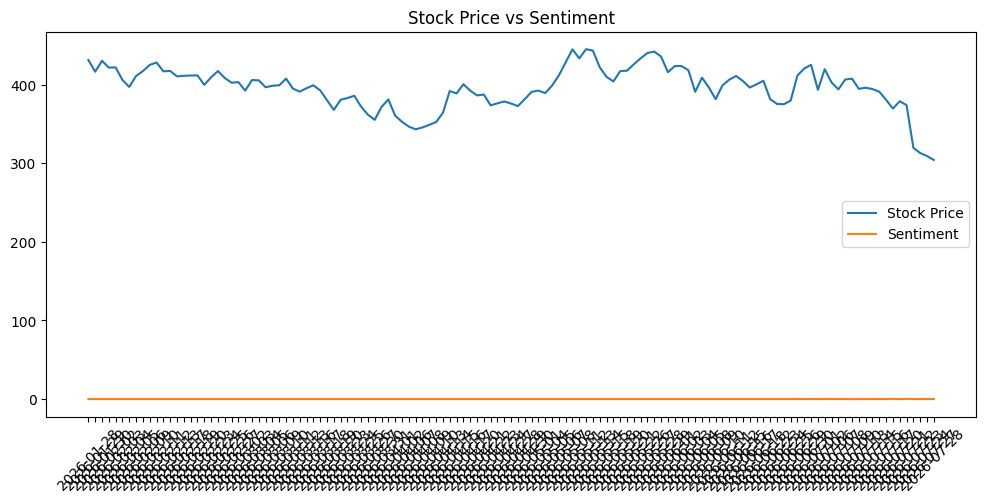

In [52]:
plt.figure(figsize=(12,5))

plt.plot(merged["Date"], merged["Close"], label="Stock Price")
plt.plot(merged["Date"], merged["sentiment"], label="Sentiment")

plt.legend()
plt.xticks(rotation=45)
plt.title("Stock Price vs Sentiment")

plt.show()

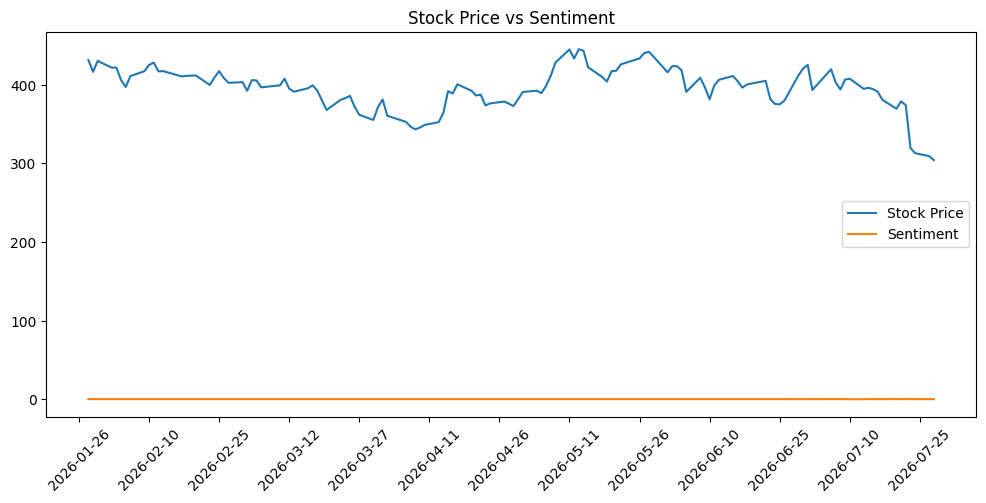

In [53]:
import matplotlib.dates as mdates

# Convert Date column properly
merged["Date"] = pd.to_datetime(merged["Date"])

plt.figure(figsize=(12,5))

plt.plot(merged["Date"], merged["Close"], label="Stock Price")
plt.plot(merged["Date"], merged["sentiment"], label="Sentiment")

# Set x-axis to show every 15 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=15))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.xticks(rotation=45)
plt.legend()
plt.title("Stock Price vs Sentiment")

plt.show()

In [54]:
correlation = merged["Close"].corr(merged["sentiment"])
print("Correlation between price and sentiment:", correlation)

Correlation between price and sentiment: -0.09357904742471415


In [55]:
merged.to_csv("final_dataset.csv", index=False)

In [56]:
print(merged.head())
print(merged.info())

        Date       Close        High         Low        Open    Volume date  \
0 2026-01-28  431.459991  438.260010  430.100006  431.910004  54857400  NaN   
1 2026-01-29  416.559998  440.230011  414.619995  437.799988  81686100  NaN   
2 2026-01-30  430.410004  439.880005  422.700012  425.350006  82626100  NaN   
3 2026-02-02  421.809998  427.149994  414.500000  421.290009  58739500  NaN   
4 2026-02-03  421.959991  428.559998  413.690002  424.269989  56886500  NaN   

   sentiment  
0        0.0  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       125 non-null    datetime64[ns]
 1   Close      125 non-null    float64       
 2   High       125 non-null    float64       
 3   Low        125 non-null    float64       
 4   Open       125 non-null    float64       
 5

In [57]:
print("Average Sentiment:", merged["sentiment"].mean())
print("Max Price:", merged["Close"].max())

Average Sentiment: 0.005486904761904761
Max Price: 445.2699890136719


In [58]:
correlation = merged["Close"].corr(merged["sentiment"])
print("Correlation:", correlation)

Correlation: -0.09357904742471415


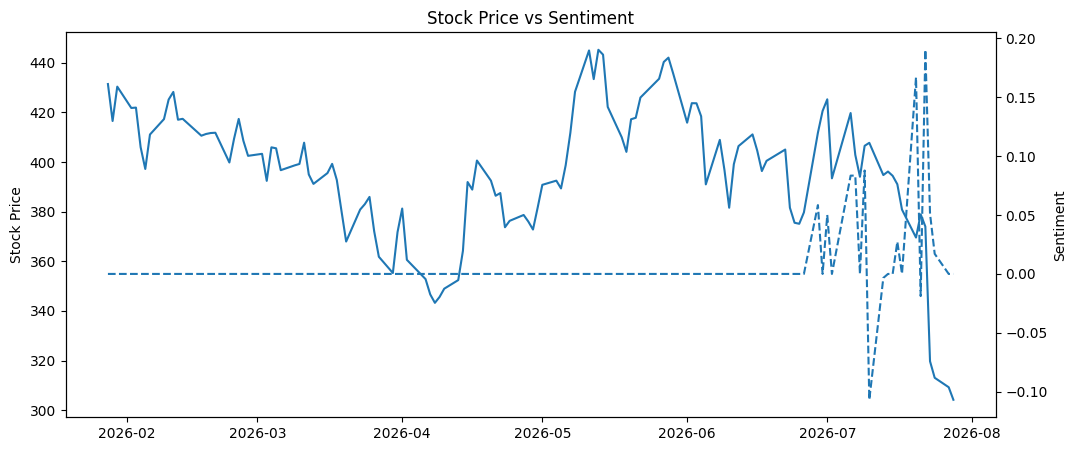

In [59]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(merged["Date"], merged["Close"], label="Stock Price")
ax1.set_ylabel("Stock Price")

ax2 = ax1.twinx()
ax2.plot(merged["Date"], merged["sentiment"], linestyle='--', label="Sentiment")
ax2.set_ylabel("Sentiment")

plt.title("Stock Price vs Sentiment")
plt.xticks(rotation=45)
plt.show()

In [60]:
merged["sentiment_lag1"] = merged["sentiment"].shift(1)

In [61]:
merged["MA_5"] = merged["Close"].rolling(5).mean()

In [62]:
def label_sentiment(x):
    if x > 0:
        return "Positive"
    elif x < 0:
        return "Negative"
    else:
        return "Neutral"

merged["sentiment_label"] = merged["sentiment"].apply(label_sentiment)